# Thermodiagrams
In this notebook we use the state variables and functions developed in the [Atmospheric Thermodynamics](atmospheric_thermodynamics.ipynb) notebook to draw two thermodynamic diagrams: an emagram and a skew-T log-P diagram. These diagram are used by meteorologists for weather forecasting. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
%run -i climate_lib.py

In [3]:
dry_adiabats = dry_adiabats()

In [4]:
t_isohumes = isohumes()

In [5]:
m_adiabats = moist_adiabats()

In [257]:
p = np.linspace(10, 100, 50) * 1000 * units.pascal

In [258]:
radiosonde_path = 'data/pratica_di_mare/2026062412-16245.csv'
radiosonde_df = pd.read_csv(radiosonde_path, index_col=0)
radiosonde_df.head(3)

,geopotential height_m,temperature_C,dew point temperature_C,ice point temperature_C,relative humidity_%,humidity wrt ice_%,mixing ratio_g/kg,wind direction_degree,wind speed_m/s
pressure_hPa,,,,,,,,,
1012.0,32,31.8,20.8,20.8,52,52,15.45,250,2.1
1009.0,59,29.4,19.4,19.4,55,55,14.18,246,2.3
1002.0,122,29.0,19.0,19.0,55,55,13.92,238,2.9


In [259]:
rs_pressure = radiosonde_df.index.to_numpy() * 100 * units.pascal
rs_pressure[:3]

Magnitude,[101200.0 100900.0 100200.0]
Units,pascal


In [260]:
rs_temperature = radiosonde_df['temperature_C'].to_numpy() * units.degK + c.T0
rs_temperature[:3]

Magnitude,[304.96000000000004 302.56 302.16]
Units,kelvin


In [261]:
len(rs_pressure)

130

## Emagrams

In [262]:
def sl_plot_emagram(rs_pressure, rs_temperature):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot()
    ax.grid(visible=True, which='major')
    ax.grid(axis='both', visible=True, which='minor')
    ax.set_xlim(-60, 40)
    ax.set_ylim(100, 10)
    ax.yaxis.set_inverted(True)
    ax.set_title("Emagram")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Pressure (kPa)")
    for i in range(len(rs_pressure)):
        ax.semilogy(rs_temperature - c.T0, rs_pressure / 1000, color='red')
    for i in range(len(dry_adiabats)):
        ax.semilogy(dry_adiabats[i] - c.T0, p / 1000, color='orange', alpha=1.0)
    for i in range(len(t_isohumes)):
        ax.semilogy(t_isohumes[i] - c.T0, p / 1000, color='blue', alpha=1.0, linestyle=':')
    for i in range(len(m_adiabats)):
        ax.semilogy(m_adiabats[i] - c.T0, p / 1000, color='orange', alpha=1.0, linestyle=':')

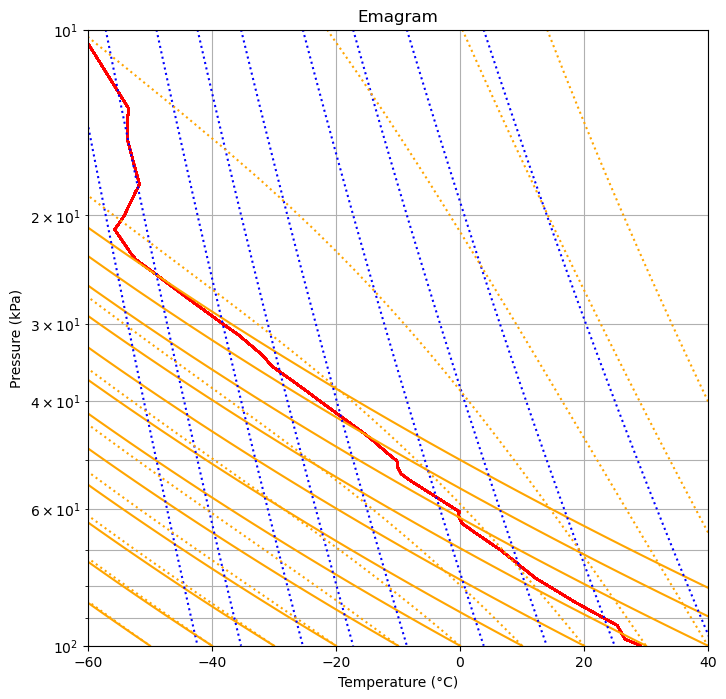

In [263]:
sl_plot_emagram(rs_pressure, rs_temperature)

## Skew-T Lop-P
In this diagram the isotherms are skewed by a factor, e.g. 35°C, so that the temperature lines are orthogonal to the dry adiabats. To build the isotherms we follow Stull, ch.5 par.5.3, p.124. 

In [275]:
def isotherms():
    '''
    This function computes a set of isotherms. The returned values
    are in Kelvin.
    '''
    temperatures = []
    p_0 = 100 * 1000 * units.pascal # Pa 
    p = np.linspace(100, 20, 50) * 1000 * units.pascal # pressure in Pa
    Y = np.log(p_0 / p) 
    t_0 = np.array([-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60]) 
    skewness_factor = 35
    for i in range(len(t_0)):
        X = t_0[i] + skewness_factor * Y.magnitude 
        X = X * units.degK + c.T0
        temperatures.append(np.flip(X))
    return temperatures 


In [276]:
skewed_Ts = isotherms()

In [277]:
def sl_plot_skekTlogP(skewed_Ts):
    p = np.linspace(10, 100, 50) * 1000
    skewed_Ts = skewed_T()
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot()
    ax.grid(visible=True, which='major')
    ax.grid(axis='both', visible=True, which='minor')
    ax.set_xlim(-50, 40)
    ax.set_ylim(100, 20)
    ax.yaxis.set_inverted(True)
    ax.set_title("Isotherms")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Pressure (kPa)")
    for i in range(len(skewed_Ts)):
        ax.semilogy(skewed_Ts[i] - c.T0, p / 1000, color='green', alpha=1.0, linestyle=':')

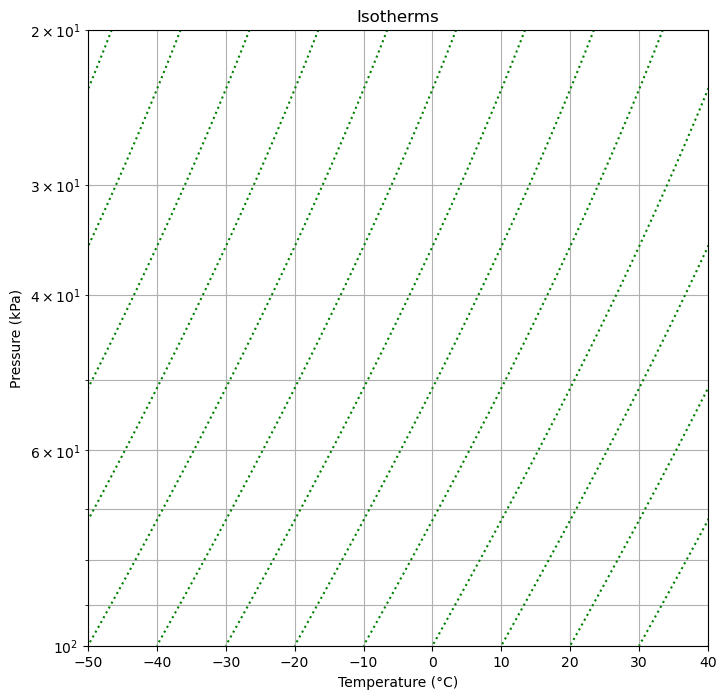

In [278]:
sl_plot_skekTlogP(skewed_Ts)

In [272]:
def sl_plot_skewTlogP(rs_pressure, rs_temperature):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot()
    ax.grid(visible=True, which='major')
    ax.grid(axis='both', visible=True, which='minor')
    ax.set_xlim(-60, 40)
    ax.set_ylim(100, 10)
    ax.yaxis.set_inverted(True)
    ax.set_title("Skew-T Log-P")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Pressure (kPa)")
    for i in range(len(rs_pressure)):
        ax.semilogy(rs_temperature - c.T0, rs_pressure / 1000, color='red')
    for i in range(len(dry_adiabats)):
        ax.semilogy(dry_adiabats[i] - c.T0, p / 1000, color='orange', alpha=1.0)
    for i in range(len(t_isohumes)):
        ax.semilogy(t_isohumes[i] - c.T0, p / 1000, color='blue', alpha=1.0, linestyle=':')
    for i in range(len(m_adiabats)):
        ax.semilogy(m_adiabats[i] - c.T0, p / 1000, color='orange', alpha=1.0, linestyle=':')
    for i in range(len(skewed_Ts)):
        ax.semilogy(skewed_Ts[i] - c.T0, p / 1000, color='green', alpha=1.0, linestyle=':')

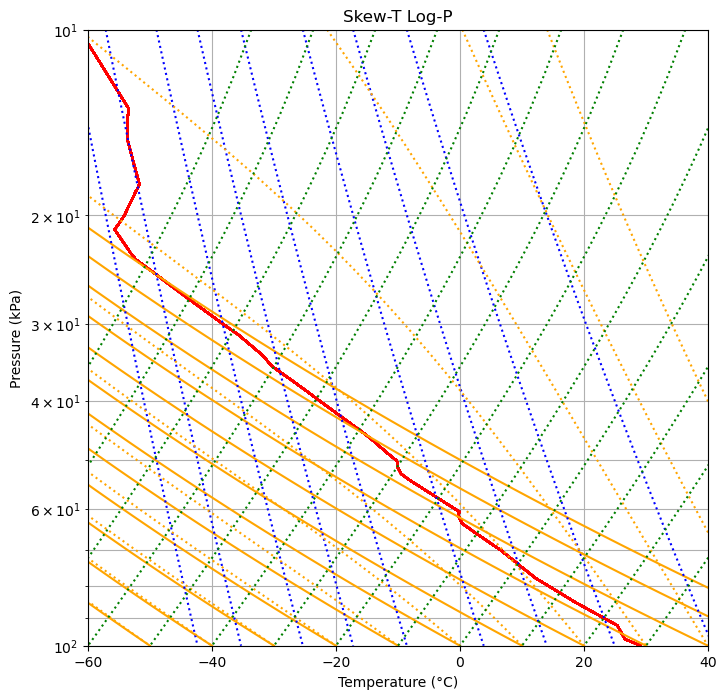

In [273]:
sl_plot_skewTlogP(rs_pressure, rs_temperature)